In [1]:
# CONNECTING TO MY GOOGLE DRIVE

# Goal: Mount Google Drive so the notebook can access the dataset
# and save processed files back to Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Confirm that the Amazon reviews dataset exists in the
# expected Google Drive folder before loading it with Spark.

import os
print(os.listdir('/content/drive/MyDrive/DATA_ANALYTICS_PROJECT/data'))

['Electronics_5.json', 'clean_reviews.parquet']


In [3]:
# Install PySpark so Spark can be used for large-scale data processing

!pip install pyspark

In [4]:
# Create a Spark session, which is the main entry point
# for working with Spark DataFrames and SQL.

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AmazonReviewAnalytics") \
    .getOrCreate()

print("Spark session started successfully!")

Spark session started successfully!


In [5]:
# Load the raw Amazon reviews dataset from Google Drive.
# The data is read as text because each row contains a JSON string.

raw_reviews = spark.read.text(
    "/content/drive/MyDrive/DATA_ANALYTICS_PROJECT/data/Electronics_5.json"
)

print("Raw dataset loaded successfully!")

Raw dataset loaded successfully!


In [6]:
# Displaying few rows of the raw data

raw_reviews.show(5, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [7]:
# DATA CLEANING AND FEATURE ENGINEERING

# Goal: Extract relevant fields from the raw JSON, clean the data,
# create useful features, and prepare a structured dataset
# for analytics.


from pyspark.sql.functions import (
    get_json_object, col, to_date, year, month, length, when
)

# Extract only the fields we need from the raw JSON text
reviews = raw_reviews.select(
    get_json_object(col("value"), "$.asin").alias("asin"),
    get_json_object(col("value"), "$.reviewerID").alias("reviewerID"),
    get_json_object(col("value"), "$.reviewText").alias("reviewText"),
    get_json_object(col("value"), "$.overall").alias("overall"),
    get_json_object(col("value"), "$.summary").alias("summary"),
    get_json_object(col("value"), "$.reviewTime").alias("reviewTime")
)

# Convert rating to numeric
reviews = reviews.withColumn("overall", col("overall").cast("float"))

# Convert review time to a real date
reviews = reviews.withColumn(
    "review_date",
    to_date(col("reviewTime"), "M d, yyyy")
)

# Extract time features
reviews = reviews.withColumn("review_year", year(col("review_date")))
reviews = reviews.withColumn("review_month", month(col("review_date")))

# Remove exact duplicates
reviews = reviews.distinct()

# Create review length feature
reviews = reviews.withColumn(
    "review_length",
    when(col("reviewText").isNotNull(), length(col("reviewText"))).otherwise(0)
)

print("Cleaned row count:", reviews.count())
reviews.printSchema()
reviews.select(
    "asin", "overall", "review_date", "review_year", "review_month", "review_length"
).show(5, truncate=False)

Cleaned row count: 6546044
root
 |-- asin: string (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- overall: float (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewTime: string (nullable = true)
 |-- review_date: date (nullable = true)
 |-- review_year: integer (nullable = true)
 |-- review_month: integer (nullable = true)
 |-- review_length: integer (nullable = true)

+----------+-------+-----------+-----------+------------+-------------+
|asin      |overall|review_date|review_year|review_month|review_length|
+----------+-------+-----------+-----------+------------+-------------+
|0545105668|5.0    |2015-06-20 |2015       |6           |807          |
|0972683275|5.0    |2016-03-11 |2016       |3           |412          |
|0972683275|3.0    |2013-08-29 |2013       |8           |122          |
|1059998254|5.0    |2016-02-19 |2016       |2           |210          |
|106171327X|4.0    |2016-09-19 |2016       |9   

In [8]:
# Store the cleaned dataset in Parquet format for faster
# loading and more efficient analysis in later steps.

reviews.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/DATA_ANALYTICS_PROJECT/data/clean_reviews.parquet"
)

print("Cleaned dataset saved as Parquet")

Cleaned dataset saved as Parquet


In [9]:
# Load the cleaned Parquet dataset

clean_reviews = spark.read.parquet(
    "/content/drive/MyDrive/DATA_ANALYTICS_PROJECT/data/clean_reviews.parquet"
)

print("Loaded Parquet successfully!")
print("Row count:", clean_reviews.count())

Loaded Parquet successfully!
Row count: 6546044


In [10]:
# Register the cleaned dataset as a temporary SQL table
# so Spark SQL queries can be used for analytics.

clean_reviews.createOrReplaceTempView("reviews")
print("SQL table created!")

SQL table created!


,overall,count,percentage
0,1.0,453163,6.92
1,2.0,297858,4.55
2,3.0,490025,7.49
3,4.0,1102231,16.84
4,5.0,4202767,64.20


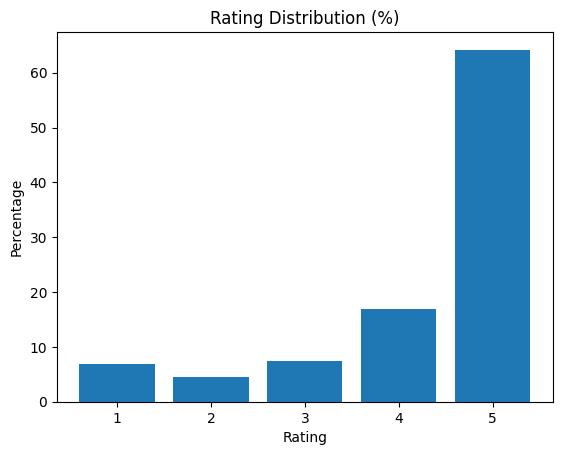

In [11]:
# RATING DISTRIBUTION

# Goal: Understand how review counts are distributed across ratings.
rating_distribution = spark.sql("""
SELECT
    overall,
    COUNT(*) AS count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentage
FROM reviews
GROUP BY overall
ORDER BY overall
""")

from IPython.display import display
display(rating_distribution.toPandas())



# Graphical Representation for Rating Distribution in %
import matplotlib.pyplot as plt

rating_distribution_pd = rating_distribution.toPandas()
plt.figure()
plt.bar(rating_distribution_pd["overall"], rating_distribution_pd["percentage"])
plt.xlabel("Rating")
plt.ylabel("Percentage")
plt.title("Rating Distribution (%)")
plt.show()


,review_year,total_reviews,percentage_of_total,avg_rating
0,1999,95,0.00,4.31
1,2000,855,0.01,4.24
2,2001,1806,0.03,4.12
3,2002,2699,0.04,4.04
4,2003,4203,0.06,3.97
5,2004,6493,0.10,3.84
6,2005,12154,0.19,3.84
7,2006,20711,0.32,3.93
8,2007,49049,0.75,4.10
9,2008,70668,1.08,4.10


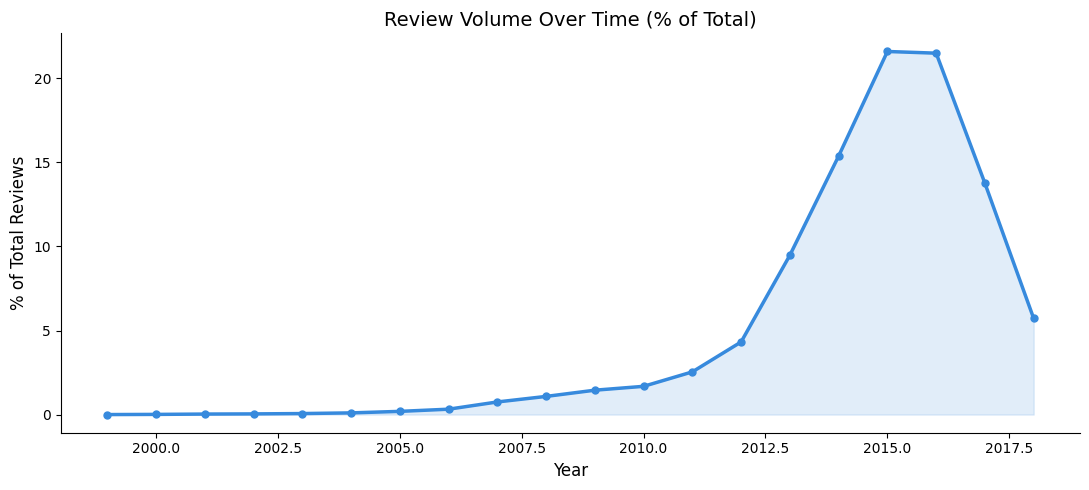

In [32]:
# REVIEWS OVER TIME

# Goal: Understand how customer satisfaction changes across years
avg_rating_over_time = spark.sql("""
SELECT
    review_year,                          -- Year of the review
    COUNT(*) AS total_reviews,            -- Number of reviews in that year
    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2
    ) AS percentage_of_total,
    ROUND(AVG(overall), 2) AS avg_rating  -- Average rating (rounded)
FROM reviews
GROUP BY review_year                      -- Group data by year
ORDER BY review_year                      -- Sort chronologically
""")

# Show tabular results
display(avg_rating_over_time.toPandas())


# Goal: Show how review volume changes over the years (In %)

import matplotlib.pyplot as plt

df = avg_rating_over_time.toPandas().sort_values('review_year')

fig, ax = plt.subplots(figsize=(11, 5))

ax.fill_between(df['review_year'], df['percentage_of_total'], alpha=0.15, color='#378ADD')
ax.plot(df['review_year'], df['percentage_of_total'], color='#378ADD', linewidth=2.5, marker='o', markersize=5)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('% of Total Reviews', fontsize=12)
ax.set_title('Review Volume Over Time (% of Total)', fontsize=14)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
# Review Length vs Rating
# Goal: Understand how review length varies across different rating levels

review_length_vs_rating = spark.sql("""
SELECT
    overall,
    ROUND(AVG(review_length), 2) AS avg_review_length,
    COUNT(*) AS total_reviews
FROM reviews
GROUP BY overall
ORDER BY overall
""")

from IPython.display import display
display(review_length_vs_rating.toPandas())

,overall,avg_review_length,total_reviews
0,1.0,422.63,453163
1,2.0,501.94,297858
2,3.0,476.71,490025
3,4.0,467.95,1102231
4,5.0,288.14,4202767


In [30]:
# Top Reviewed Products

# Goal: Identify the most frequently reviewed products

top_products = spark.sql("""
SELECT
    asin,
    COUNT(*) AS review_count,
    ROUND(AVG(overall), 2) AS avg_rating
FROM reviews
GROUP BY asin
ORDER BY review_count DESC
LIMIT 10
""")
display(top_products.toPandas())



,asin,review_count,avg_rating
0,B003L1ZYYW,8609,4.79
1,B0019HL8Q8,8017,4.76
2,B0019EHU8G,7641,4.76
3,B00DIF2BO2,6222,4.47
4,B00M55C0NS,6219,4.73
5,B00BWF5U0M,6182,4.50
6,B000BQ7GW8,5984,4.71
7,B00IVPU7AO,5983,4.46
8,B00L0YLRUW,5696,4.06
9,B0043T7FXE,5457,4.48


In [17]:
# INSTALL NLP LIBRARY

# Goal: Install NLTK so VADER sentiment analysis can be used
# to analyze review text.

!pip install nltk

In [18]:
# Downloading the VADER model
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [19]:
# Initialize sentiment analyzer
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Testing it
print(sia.polarity_scores("This product is amazing!"))
print(sia.polarity_scores("This is terrible and disappointing"))

{'neg': 0.0, 'neu': 0.423, 'pos': 0.577, 'compound': 0.6239}
{'neg': 0.677, 'neu': 0.323, 'pos': 0.0, 'compound': -0.743}


In [20]:
# APPLY SENTIMENT ANALYSIS TO SAMPLE

# Goal: Use VADER to classify review text as positive, negative,
# or neutral on a 1% sample of the cleaned dataset.

from pyspark.sql.functions import udf, col
from pyspark.sql.types import StringType

def get_sentiment(text):
    """
    Takes a review text and returns a sentiment label
    based on VADER's compound score.
    """
    if text is None:
        return "neutral"

    score = sia.polarity_scores(text)["compound"]

    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

sentiment_udf = udf(get_sentiment, StringType())

sample_reviews = clean_reviews.sample(fraction=0.01, seed=42)

sample_reviews = sample_reviews.withColumn(
    "sentiment",
    sentiment_udf(col("reviewText"))
)

sample_reviews.select(
    "reviewText",
    "overall",
    "sentiment"
).show(5, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [24]:
# SENTIMENT DISTRIBUTION
# Count how many reviews fall into each sentiment category

sentiment_dist = sample_reviews.groupBy("sentiment").count()
display(sentiment_dist.toPandas())

,sentiment,count
0,positive,51473
1,neutral,5674
2,negative,8367


In [26]:
# Create SQL table
sample_reviews.createOrReplaceTempView("sample_reviews")


# Comparing sentiment classification with star ratings
sentiment_vs_rating = spark.sql("""
SELECT
    overall,                     -- Star rating
    sentiment,                   -- NLP classification
    COUNT(*) AS count            -- Number of reviews
FROM sample_reviews
GROUP BY overall, sentiment
ORDER BY overall, sentiment
""")

from IPython.display import display
display(sentiment_vs_rating.toPandas())

,overall,sentiment,count
0,1.0,negative,2401
1,1.0,neutral,626
2,1.0,positive,1603
3,2.0,negative,1281
4,2.0,neutral,353
5,2.0,positive,1446
6,3.0,negative,1258
7,3.0,neutral,508
8,3.0,positive,3091
9,4.0,negative,1179


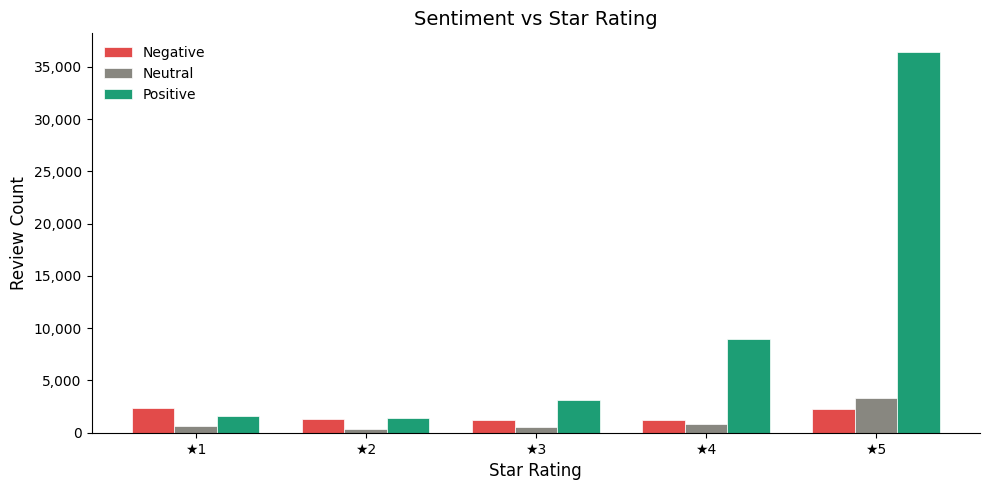

In [28]:
# A visualization of sentiment classification with star ratings

import matplotlib.pyplot as plt
import pandas as pd

# Convert to pandas
df = sentiment_vs_rating.toPandas()

# Pivot so each sentiment becomes a column
pivot = df.pivot(index='overall', columns='sentiment', values='count')[['negative', 'neutral', 'positive']]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(pivot.index))
width = 0.25
colors = {'negative': '#E24B4A', 'neutral': '#888780', 'positive': '#1D9E75'}

for i, sentiment in enumerate(['negative', 'neutral', 'positive']):
    ax.bar([p + i * width for p in x], pivot[sentiment], width,
           label=sentiment.capitalize(), color=colors[sentiment],
           edgecolor='white', linewidth=0.5)

ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Review Count', fontsize=12)
ax.set_title('Sentiment vs Star Rating', fontsize=14)
ax.set_xticks([p + width for p in x])
ax.set_xticklabels([f'★{int(r)}' for r in pivot.index])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()